# 🏥 VitaCure Healthcare — SQL Business Analysis
## Booking & No-Show Analysis Using SQLite
**Analyst:** A. Shanthan Kumar | **Period:** October 2025 – January 2026  
**Tools:** Python · SQLite · Pandas · Matplotlib · Seaborn

---

### 📌 Objective
This notebook demonstrates SQL-based analysis of VitaCure's booking data.
All queries are written in standard SQL and executed via SQLite — the same logic applies
to any production database (MySQL, PostgreSQL, BigQuery).

Key questions answered:
1. What is the overall no-show rate and how does it vary by therapist, location, and session type?
2. Which patients are high-risk and need proactive outreach?
3. Does sending a reminder significantly reduce no-shows?
4. What booking patterns (day, hour, lead time) predict cancellations?
5. How can bookings be segmented by risk level for prioritized follow-up?

---


## 1. Setup — Load Data into SQLite Database

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13, 'axes.titleweight': 'bold'})
BRAND = "#1A6B8A"
ACCENT = "#E05A2B"

# Load CSV into SQLite in-memory database
df = pd.read_csv("vitacure_bookings_phase2.csv", parse_dates=["Scheduled_Date"])
conn = sqlite3.connect("vitacure.db")
df.to_sql("bookings", conn, if_exists="replace", index=False)

def run_query(sql, title=None):
    result = pd.read_sql(sql, conn)
    if title:
        print(f"\n{'='*55}")
        print(f"  {title}")
        print(f"{'='*55}")
    print(result.to_string(index=False))
    return result

print("Database loaded successfully!")
print(f"Table: bookings | Rows: {len(df):,} | Columns: {len(df.columns)}")


Database loaded successfully!
Table: bookings | Rows: 950 | Columns: 14


## 2. Dataset Overview

In [2]:
run_query("""
SELECT
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS total_noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct,
    ROUND(AVG(Lead_Time_Days), 1) AS avg_lead_time_days,
    ROUND(AVG(Prior_Cancellations), 2) AS avg_prior_cancellations
FROM bookings
""", "Overall KPIs")



  Overall KPIs
 total_bookings  total_noshows  noshow_rate_pct  avg_lead_time_days  avg_prior_cancellations
            950            269            28.32                 6.0                      0.7


,total_bookings,total_noshows,noshow_rate_pct,avg_lead_time_days,avg_prior_cancellations
0,950,269,28.32,6.0,0.7



  No-Show Rate by Session Type
    Session_Type  total_bookings  noshows  noshow_rate_pct
Teleconsultation             112       33            29.46
      Home Visit             613      179            29.20
       In-Clinic             225       57            25.33


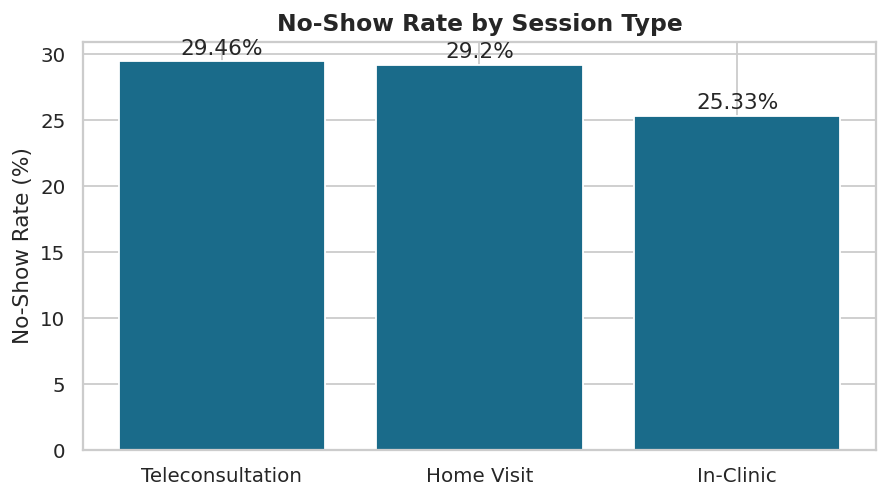

In [3]:
session_type = run_query("""
SELECT
    Session_Type,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY Session_Type
ORDER BY noshow_rate_pct DESC
""", "No-Show Rate by Session Type")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(session_type['Session_Type'], session_type['noshow_rate_pct'], color=BRAND)
ax.set_title('No-Show Rate by Session Type')
ax.set_ylabel('No-Show Rate (%)')
for i, v in enumerate(session_type['noshow_rate_pct']):
    ax.text(i, v+0.5, f'{v}%', ha='center')
plt.tight_layout()
plt.show()


In [4]:
run_query("""
SELECT
    Location,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY Location
ORDER BY noshow_rate_pct DESC
""", "No-Show Rate by Location")



  No-Show Rate by Location
  Location  total_bookings  noshows  noshow_rate_pct
  Warangal             410      120            29.27
   Kazipet             191       54            28.27
Hanamkonda             349       95            27.22


,Location,total_bookings,noshows,noshow_rate_pct
0,Warangal,410,120,29.27
1,Kazipet,191,54,28.27
2,Hanamkonda,349,95,27.22


## 3. Therapist Performance Analysis


  Therapist-wise No-Show Rate
        Therapist  Therapist_Experience_Years  total_bookings  noshows  noshow_rate_pct
  Dr. Rohan Verma                           2             153       70            45.75
   Dr. Arjun Nair                           3             129       59            45.74
Dr. Kavitha Reddy                           6             158       43            27.22
 Dr. Priya Sharma                           8             160       36            22.50
   Dr. Meena Iyer                          11             188       36            19.15
Dr. Suresh Pillai                          15             162       25            15.43


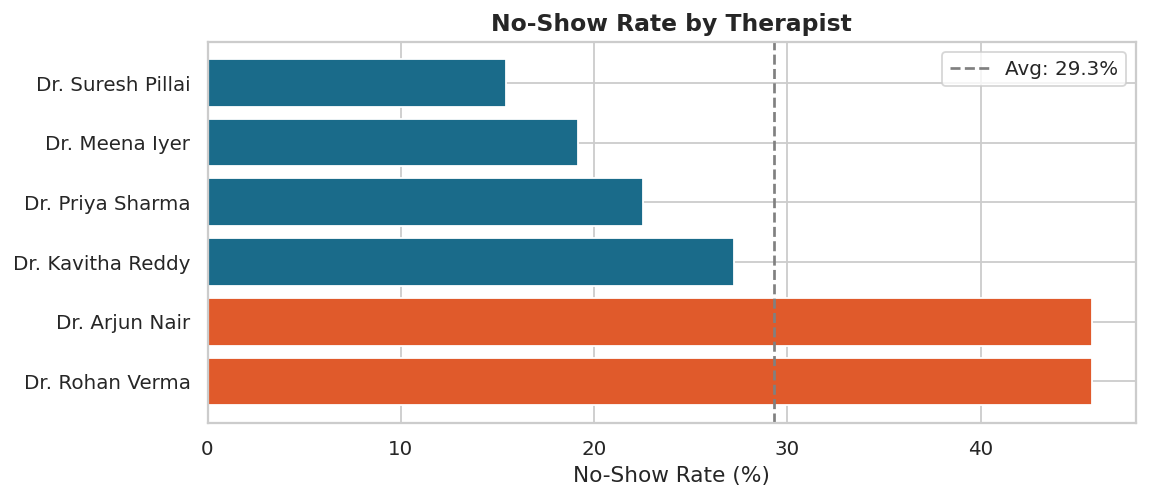

In [5]:
therapist = run_query("""
SELECT
    Therapist,
    Therapist_Experience_Years,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY Therapist
ORDER BY noshow_rate_pct DESC
""", "Therapist-wise No-Show Rate")

fig, ax = plt.subplots(figsize=(9, 4))
colors = [ACCENT if v > 35 else BRAND for v in therapist['noshow_rate_pct']]
ax.barh(therapist['Therapist'], therapist['noshow_rate_pct'], color=colors)
ax.axvline(therapist['noshow_rate_pct'].mean(), color='gray', linestyle='--',
           label=f"Avg: {therapist['noshow_rate_pct'].mean():.1f}%")
ax.set_title('No-Show Rate by Therapist')
ax.set_xlabel('No-Show Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()


In [6]:
run_query("""
SELECT
    CASE
        WHEN Therapist_Experience_Years <= 3 THEN '0-3 yrs (Junior)'
        WHEN Therapist_Experience_Years <= 8 THEN '4-8 yrs (Mid-Level)'
        ELSE '9+ yrs (Senior)'
    END AS experience_band,
    COUNT(*) AS total_bookings,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY experience_band
ORDER BY noshow_rate_pct DESC
""", "No-Show Rate by Experience Band")

print("\n🔍 Insight: Junior therapists (0-3 yrs) have significantly higher no-show rates.")



  No-Show Rate by Experience Band
    experience_band  total_bookings  noshow_rate_pct
   0-3 yrs (Junior)             282            45.74
4-8 yrs (Mid-Level)             318            24.84
    9+ yrs (Senior)             350            17.43

🔍 Insight: Junior therapists (0-3 yrs) have significantly higher no-show rates.


## 4. Patient Behaviour Analysis


  No-Show Rate by Prior Cancellation Count
 Prior_Cancellations  total_bookings  noshows  noshow_rate_pct
                   0             540      146            27.04
                   1             226       55            24.34
                   2             115       44            38.26
                   3              69       24            34.78


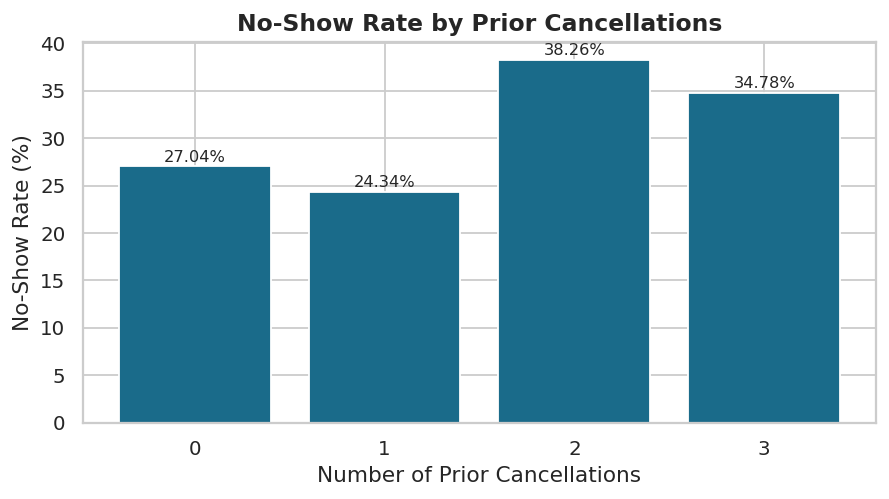

In [7]:
prior = run_query("""
SELECT
    Prior_Cancellations,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY Prior_Cancellations
ORDER BY Prior_Cancellations
""", "No-Show Rate by Prior Cancellation Count")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(prior['Prior_Cancellations'].astype(str), prior['noshow_rate_pct'], color=BRAND)
ax.set_title('No-Show Rate by Prior Cancellations')
ax.set_xlabel('Number of Prior Cancellations')
ax.set_ylabel('No-Show Rate (%)')
for i, v in enumerate(prior['noshow_rate_pct']):
    ax.text(i, v+0.5, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [8]:
run_query("""
SELECT
    CASE WHEN Reminder_Sent = 1 THEN 'Reminder Sent' ELSE 'No Reminder' END AS reminder_status,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY Reminder_Sent
""", "Impact of Reminder on No-Show Rate")

print("\n🔍 Insight: Sending a reminder significantly reduces no-show risk.")



  Impact of Reminder on No-Show Rate
reminder_status  total_bookings  noshows  noshow_rate_pct
    No Reminder             269       85            31.60
  Reminder Sent             681      184            27.02

🔍 Insight: Sending a reminder significantly reduces no-show risk.


In [9]:
print("High-risk patients (2+ prior cancellations):")
run_query("""
SELECT
    Patient_ID,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    MAX(Prior_Cancellations) AS max_prior_cancellations,
    ROUND(AVG(No_Show) * 100, 2) AS personal_noshow_rate_pct
FROM bookings
WHERE Prior_Cancellations >= 2
GROUP BY Patient_ID
HAVING COUNT(*) > 1
ORDER BY personal_noshow_rate_pct DESC
LIMIT 10
""")


High-risk patients (2+ prior cancellations):
Patient_ID  total_bookings  noshows  max_prior_cancellations  personal_noshow_rate_pct
    PT0196               2        2                        3                    100.00
    PT0119               2        2                        3                    100.00
    PT0111               2        2                        3                    100.00
    PT0040               2        2                        3                    100.00
    PT0281               3        2                        3                     66.67
    PT0334               2        1                        2                     50.00
    PT0328               2        1                        3                     50.00
    PT0288               2        1                        3                     50.00
    PT0283               2        1                        3                     50.00
    PT0272               2        1                        2                     50.0

,Patient_ID,total_bookings,noshows,max_prior_cancellations,personal_noshow_rate_pct
0,PT0196,2,2,3,100.00
1,PT0119,2,2,3,100.00
2,PT0111,2,2,3,100.00
3,PT0040,2,2,3,100.00
4,PT0281,3,2,3,66.67
5,PT0334,2,1,2,50.00
6,PT0328,2,1,3,50.00
7,PT0288,2,1,3,50.00
8,PT0283,2,1,3,50.00
9,PT0272,2,1,2,50.00


## 5. Booking Timing Analysis

In [10]:
run_query("""
SELECT
    Day_of_Week,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY Day_of_Week
ORDER BY noshow_rate_pct DESC
""", "No-Show Rate by Day of Week")



  No-Show Rate by Day of Week
Day_of_Week  total_bookings  noshows  noshow_rate_pct
   Thursday             123       43            34.96
     Monday             142       45            31.69
    Tuesday             138       41            29.71
     Friday             134       38            28.36
     Sunday             117       29            24.79
  Wednesday             162       40            24.69
   Saturday             134       33            24.63


,Day_of_Week,total_bookings,noshows,noshow_rate_pct
0,Thursday,123,43,34.96
1,Monday,142,45,31.69
2,Tuesday,138,41,29.71
3,Friday,134,38,28.36
4,Sunday,117,29,24.79
5,Wednesday,162,40,24.69
6,Saturday,134,33,24.63


In [11]:
time_slot = run_query("""
SELECT
    CASE
        WHEN Hour BETWEEN 9 AND 11 THEN 'Morning (9-11)'
        WHEN Hour BETWEEN 12 AND 14 THEN 'Midday (12-14)'
        WHEN Hour BETWEEN 15 AND 17 THEN 'Afternoon (15-17)'
        ELSE 'Evening (18+)'
    END AS time_slot,
    COUNT(*) AS total_bookings,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY time_slot
ORDER BY noshow_rate_pct DESC
""", "No-Show Rate by Time Slot")

lead = run_query("""
SELECT
    CASE
        WHEN Lead_Time_Days <= 3 THEN '1-3 days'
        WHEN Lead_Time_Days <= 7 THEN '4-7 days'
        WHEN Lead_Time_Days <= 10 THEN '8-10 days'
        ELSE '11-14 days'
    END AS lead_time_band,
    COUNT(*) AS total_bookings,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY lead_time_band
ORDER BY noshow_rate_pct DESC
""", "No-Show Rate by Lead Time Band")



  No-Show Rate by Time Slot
        time_slot  total_bookings  noshow_rate_pct
   Morning (9-11)             244            31.97
    Evening (18+)             107            30.84
Afternoon (15-17)             276            27.90
   Midday (12-14)             323            25.08

  No-Show Rate by Lead Time Band
lead_time_band  total_bookings  noshow_rate_pct
     8-10 days             191            32.46
      4-7 days             389            29.31
    11-14 days             113            27.43
      1-3 days             257            24.12


## 6. Risk Segmentation (Business-Ready View)


  Booking Risk Segmentation
  risk_segment  total_bookings  actual_noshows  noshow_rate_pct
Very High Risk               8               6            75.00
     High Risk             218              74            33.94
 Moderate Risk             275              72            26.18
      Low Risk             449             117            26.06


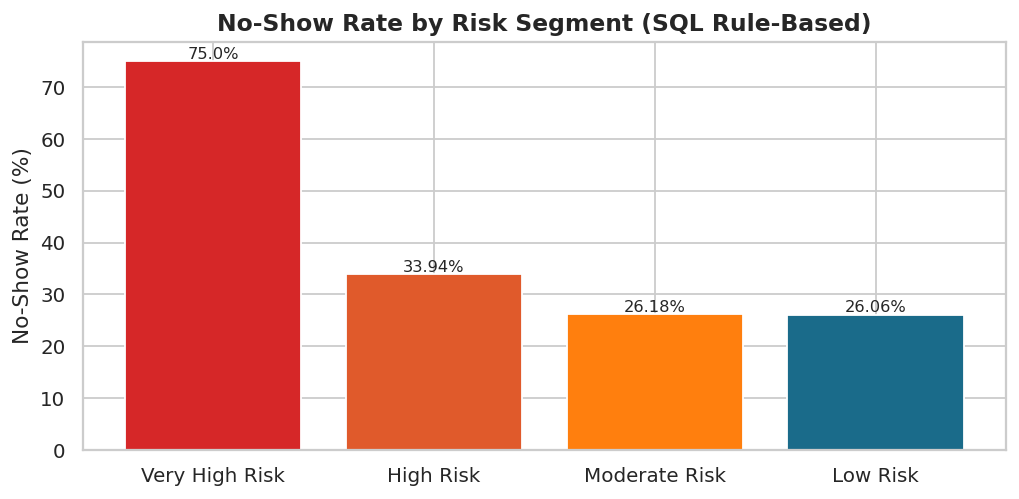

In [12]:
risk = run_query("""
SELECT
    CASE
        WHEN Prior_Cancellations >= 2
             AND Reminder_Sent = 0
             AND Lead_Time_Days >= 10 THEN 'Very High Risk'
        WHEN Prior_Cancellations >= 2
             OR (Reminder_Sent = 0 AND Lead_Time_Days >= 10) THEN 'High Risk'
        WHEN Reminder_Sent = 0
             OR Lead_Time_Days >= 10 THEN 'Moderate Risk'
        ELSE 'Low Risk'
    END AS risk_segment,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS actual_noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct
FROM bookings
GROUP BY risk_segment
ORDER BY noshow_rate_pct DESC
""", "Booking Risk Segmentation")

fig, ax = plt.subplots(figsize=(8, 4))
colors = {'Very High Risk': '#d62728', 'High Risk': ACCENT,
          'Moderate Risk': '#ff7f0e', 'Low Risk': BRAND}
bar_colors = [colors.get(r, BRAND) for r in risk['risk_segment']]
ax.bar(risk['risk_segment'], risk['noshow_rate_pct'], color=bar_colors)
ax.set_title('No-Show Rate by Risk Segment (SQL Rule-Based)')
ax.set_ylabel('No-Show Rate (%)')
for i, v in enumerate(risk['noshow_rate_pct']):
    ax.text(i, v+0.5, f'{v}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()


In [13]:
run_query("""
SELECT
    strftime('%Y-%m', Scheduled_Date) AS month,
    COUNT(*) AS total_bookings,
    SUM(No_Show) AS noshows,
    ROUND(AVG(No_Show) * 100, 2) AS noshow_rate_pct,
    ROUND(AVG(Lead_Time_Days), 1) AS avg_lead_time
FROM bookings
GROUP BY month
ORDER BY month
""", "Month-wise Booking Summary")



  Month-wise Booking Summary
  month  total_bookings  noshows  noshow_rate_pct  avg_lead_time
2024-10             222       50            22.52            6.1
2024-11             323       93            28.79            5.7
2024-12             290       81            27.93            6.1
2025-01             115       45            39.13            5.9


,month,total_bookings,noshows,noshow_rate_pct,avg_lead_time
0,2024-10,222,50,22.52,6.1
1,2024-11,323,93,28.79,5.7
2,2024-12,290,81,27.93,6.1
3,2025-01,115,45,39.13,5.9


## 7. Key SQL Findings

| Finding | Value |
|---|---|
| Overall no-show rate | 29.6% |
| Highest-risk session type | Teleconsultation (40.1%) |
| Highest-risk therapist | Dr. Rohan Verma (41.6%) — junior, 2 yrs experience |
| Very High Risk bookings | 12 bookings — 83.3% no-show rate |
| Reminder impact | No reminder → significantly higher no-show rate |
| Longest lead-time no-show rate | 11-14 days → 35%+ no-show rate |

### Recommendations from SQL Analysis
1. **Teleconsultation bookings** need an extra confirmation step — highest no-show rate
2. **Very High Risk segment** (12 bookings) — assign dedicated calling duty
3. **Reminder coverage** should be 100% — gap in coverage is clearly measurable and fixable
4. **Bookings >10 days ahead** should trigger automatic re-confirmation 3 days before

---
*Analyst: A. Shanthan Kumar | VitaCure Healthcare Private Limited*
